In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.models import Model # 함수형으로 신경망 모델을 만들기 위해 import 한다.
from tensorflow.keras.layers import Input # 함수형 신경망에 입력하는 데이터의 형태를 지정하기 위해 import 한다.
from tensorflow.keras.layers import Conv2D # 신경망에 추가할 합성곱 레이어를 생성하기 위해 import 한다.
from tensorflow.keras.layers import MaxPool2D # 신경망에 추가할 맥스 풀링 레이어를 생성하기 위해 import 한다.
# 다운 샘플링(Down Sampling)은 이미지 크기를 줄여가며 특징을 추출하는 과정이고 업 샘플링(Up Sampling)은 다운 샘플링된 이미지를 원래 이미지로 복원하는 과정이다.
from tensorflow.keras.layers import UpSampling2D # 신경망에 업 샘플링 레이어를 생성하기 위해 import 한다.

오토 인코더(auto encoder)

오토 인코더는 신경망의 한 종류로 데이터를 코드(code)라고 부르는 은닉층으로 인코딩하는 인코더(encoder) 부분과 인코딩된 코드를 다시 디코딩하는 디코더(decoder)로 구성되어 있다. 인코딩은 원래 데이터를 차원 축소하는 것을 의미하고, 디코딩은 차원 축소된 데이터를 다시 원래 데이터로 복원하는 것을 의미한다.

<img src="./autoEncoder_1.png" width="700" align="left" />

오토 인코더의 시작은 차원 축소와 관련이 있는데 초기 인코더는 주성분 분석 같은 차원 축소를 위해 사용했지만, 현재는 데이터 생성 모델로도 사용된다.

오토 인코더를 이용해서 손글씨 이미지 데이터의 노이즈를 없애본다.

오토 인코더에 사용할 데이터를 준비한다.

In [2]:
# 손글씨 숫자 데이터셋을 학습 데이터와 테스트 데이터로 저장한다.
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
# 데이터 확인
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


원본 데이터 시각화

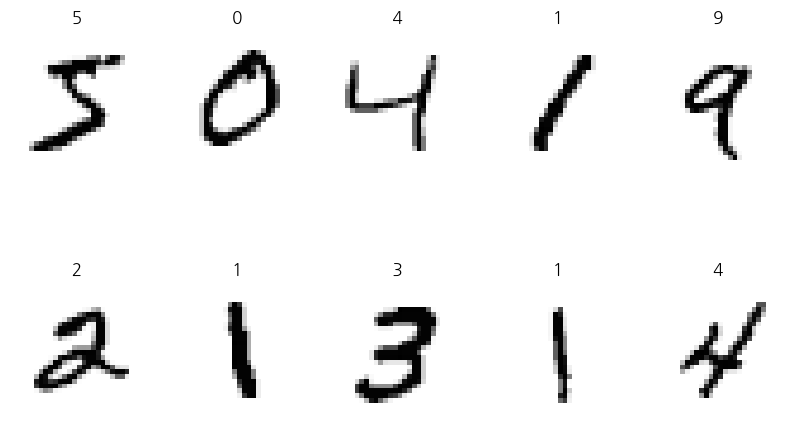

In [3]:
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='Grays')
    plt.axis('off')
    plt.title(y_train[i])
plt.show()

레이블 종류 확인

In [4]:
# 회귀 문제인지 분류 문제인지 파악할 수 있고 분류 문제라면 몇 개의 클래스로 구분되는지 알 수 있다.
print(set(y_train))

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


피쳐 데이터 차원 변경

In [5]:
# 합성곱 신경망에서 사용할 이미지 데이터는 reshape() 메소드를 이용해서 (이미지 개수, 이미지의 행, 이미지의 열, 채널 개수) 형태로 변형해서 사용한다.
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


피쳐 데이터 스케일 조정

In [6]:
# 이미지의 픽셀값은 0 ~ 255 사이에 있으므로 최소값은 0, 최대값 1이 되도록 조정한다.
x_train = x_train / 255
x_test = x_test / 255

원본 데이터에 노이즈를 추가한 데이터를 만든다.

In [7]:
# mnist 데이터셋은 노이즈 데이터셋을 별도로 제공하지 않기때문에 원본 학습 데이터에 랜덤값을 더해서 노이즈 데이터를 생성한다.
x_train_noise = x_train + np.random.uniform(-1, 1, size=x_train.shape)
x_test_noise = x_test + np.random.uniform(-1, 1, size=x_test.shape)
print(x_train_noise.shape, x_test_noise.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


노이즈 데이터 스케일링

In [8]:
# 노이즈 데이터를 생성하는 과정에서 픽셀값이 0보다 작아지거나 1보다 커질 가능성이 있어서 스케일을 조정한다.
# numpy의 clip() 메소드를 사용하면 값의 범위를 a_min 속성과 a_max 속성값 사이의 값으로 조정한다.
# a_min 속성값을 0으로 설정하면 0보다 작은값은 모두 0이 되고, a_max 속성값을 1로 지정하면 1보다 큰값은 모두 1이 된다.
x_train_noise = np.clip(x_train_noise, a_min=0, a_max=1)
x_test_noise = np.clip(x_test_noise, a_min=0, a_max=1)

원본 데이터에 노이즈를 적용한 데이터 시각화

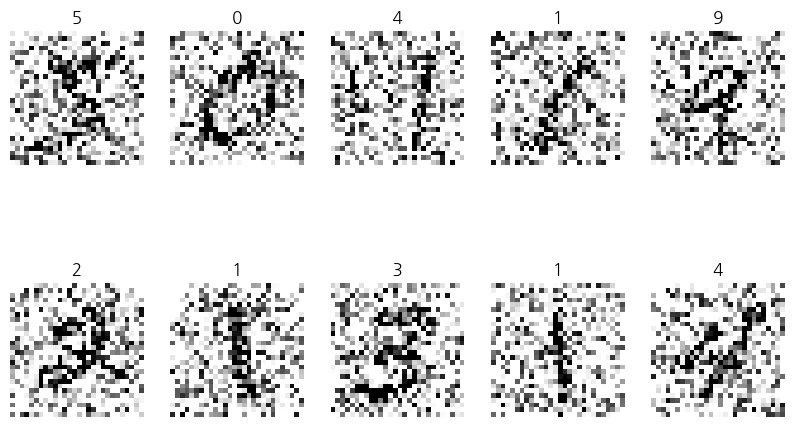

In [9]:
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_noise[i], cmap='Grays')
    plt.axis('off')
    plt.title(y_train[i])
plt.show()

오토 인코더의 인코더 부분으로 사용할 신경망 모델을 만든다.

In [10]:
# 인코더 모델에 추가할 입력 레이어를 만든다.
# Input 레이어의 Output Shape은 Input 레이어의 shape 속성값을 따른다. (None, 28, 28, 1)
# Input 레이어의 Param은 이전 레이어가 없이 때문에 0이다.
input_layer = Input(shape=(28, 28, 1)) # 입력 데이터 1건의 크기를 지정한다.

# 인코더 모델에 추가할 히든 레이어를 만든다.
# filters 속성으로 레이어의 출력 차원, kernel_size 속성으로 커널의 크기, padding 속성으로 패딩 사용 여부, activation 속성으로 활성화 함수를 지정한다.
# Conv2D 레이어의 Output Shape은 filters 속성값과 padding 속성값에 의해서 결정된다.
# padding 속성값으로 'same'를 지정해서 패딩을 적용하면 데이터의 차원이 변경되지 않는다. (None, 28, 28, 32)
# padding 속성값으로 'valid'를 지정했다면 데이터의 차원이 '입력 데이터 차원(28) + 1 - 커널의 차원(5)' = 28 + 1 - 5 = 24로 변경된다. (None, 24, 24, 32)
# Conv2D 레이어의 Param은 '커널의 크기(5 * 5) * 입력 채널 크기(1) * 필터 크기(32) + 필터마다 1개의 바이어스(32)' = 25 * 1 * 32 + 32 = 832가 된다.
hidden_layer = Conv2D(filters=32, kernel_size=(5, 5), padding='same', activation='relu')(input_layer)

# 인코더 모델에 추가할 출력 레이어를 만든다.
# pool_size 속성으로 맥스 풀링을 실행할 픽셀의 크기, padding 속성으로 패딩 사용 여부를 지정한다.
# MaxPool2D 레이어의 Output Shape은 '입력 데이터의 차원(28) / 맥스 풀링의 차원(2)' 의해서 결정된다. 28 / 2 = 14, (None, 14, 14, 32)
# MaxPool2D 레이어의 Param은 없으므로 0이다.
output_layer = MaxPool2D(pool_size=(2, 2), padding='same')(hidden_layer)

# 인코더 모델을 만든다.
# Model 객체에 입력 레이어와 출력 레이어를 넘겨서 신경망 모델을 만든다.
encoder = Model(input_layer, output_layer)

encoder.summary()



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        832       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
Total params: 832 (3.25 KB)
Trainable params: 832 (3.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


오토 인코더의 디코더 부분으로 사용할 신경망 모델을 만든다.

In [11]:
print(output_layer.shape)
print(output_layer.shape[1:4])

(None, 14, 14, 32)
(14, 14, 32)


In [12]:
# 디코더 모델에 추가할 입력 레이어를 만든다.
# 디코더는 인코더의 출력을 입력으로 받아야하므로 디코더 모델의 Input 레이어에 입력되는 데이터의 차원은 인코더 모델의 출력 차원과 같다.
# Input 레이어의 Output Shape은 Input 레이어의 shape 속성값을 따른다. (None, 14, 14, 32)
# Input 레이어의 Param은 이전 레이어가 없이 때문에 0이다.
input_layer = Input(shape=output_layer.shape[1:4])

# 디코더 모델에 추가할 히든 레이어를 만든다.
# filters 속성으로 레이어의 출력 차원, kernel_size 속성으로 커널의 크기, padding 속성으로 패딩 사용 여부, activation 속성으로 활성화 함수를 지정한다.
# Conv2D 레이어의 Output Shape은 filters 속성값과 padding 속성값에 의해서 결정된다.
# padding 속성값으로 'same'를 지정해서 패딩을 적용하면 데이터의 차원이 변경되지 않는다. (None, 14, 14, 10)
# padding 속성값으로 'valid'를 지정했다면 데이터의 차원이 '입력 데이터 차원(14) + 1 - 커널의 차원(5)' = 14 + 1 - 5 = 10으로 변경된다. (None, 10, 10, 10)
# Conv2D 레이어의 Param은 '커널의 크기(5 * 5) * 입력 채널 크기(32) * 필터 크기(10) + 필터마다 1개의 바이어스(10)' = 25 * 32 * 10 + 10 = 8010가 된다.
hidden_layer = Conv2D(filters=10, kernel_size=(5, 5), padding='same', activation='relu')(input_layer)

# 디코더 모델에 인코더 모델에서 맥스 풀링에 의해서 줄어들었던 차원으로 다시 높여주기 위해서 UpSampling2D 레이어를 만든다.
# size 속성으로 원상 복구할 픽셀의 크기(맥스 풀링에서 pool_size 속성값 만큼)를 지정한다.
# UpSampling2D 레이어의 Output Shape은 size 속성값에 의해서 압축되기 전 차원으로 변환된다. (None, 28, 28, 10)
# UpSampling2D 레이어의 Param은 없으므로 0이다.
hidden_layer = UpSampling2D(size=(2, 2))(hidden_layer)

# 디코더 모델에 추가할 출력 레이어를 만든다.
# 디코더의 최종 출력 채널의 개수는 최초 입력 이미지의 채널 개수와 같아야 하므로 filters 속성값으로 1을 지정한다.
# Conv2D 레이어의 Output Shape은 filters 속성값과 padding 속성값에 의해서 결정된다.
# padding 속성값으로 'same'를 지정해서 패딩을 적용하면 데이터의 차원이 변경되지 않는다. (None, 28, 28, 1)
# Conv2D 레이어의 Param은 '커널의 크기(5 * 5) * 입력 채널 크기(10) * 필터 크기(1) + 필터마다 1개의 바이어스(1)' = 25 * 10 * 1 + 1 = 251이 된다.
output_layer = Conv2D(filters=1, kernel_size=(5, 5), padding='same', activation='relu')(hidden_layer)

# 디코더 모델을 만든다.
# Model 객체에 입력 레이어와 출력 레이어를 넘겨서 신경망 모델을 만든다.
decoder = Model(input_layer, output_layer)

decoder.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 14, 14, 32)]      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 10)        8010      
                                                                 
 up_sampling2d (UpSampling2  (None, 28, 28, 10)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 1)         251       
                                                                 
Total params: 8261 (32.27 KB)
Trainable params: 8261 (32.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


인코더 신경망 모델과 디코더 신경망 모델을 합쳐서 오토 인코더 신경망 모델로 만든다.

오토 인코더는 최초 입력값을 인코더에 먼저 넣고 인코더의 출력을 디코더에 넣어준다.

In [13]:
# 오토 인코더 신경망 모델에 넣어줄 입력 레이어를 만든다.
# Input 레이어의 Output Shape은 Input 레이어의 shape 속성값을 따른다. (None, 28, 28, 1)
# Input 레이어의 Param은 이전 레이어가 없이 때문에 0이다.
input_auto = Input(shape=(28, 28, 1))

# 오토 인코더 신경망 모델에 넣어줄 출력 레이어를 만든다.
# 인코더의 Output Shape은 인코더 신경망 최종 출력의 Output Shape을 따른다. (None, 14, 14, 32)
# 인코더의 Param은 인코더 신경망의 모든 Param을 더한 값을 따른다. 0 + 832 + 0 = 832
# 디코더의 Output Shape은 디코더 신경망 최종 출력의 Output Shape을 따른다. (None, 28, 28, 1)
# 디코더의 Param은 디코더 신경망의 모든 Param을 더한 값을 따른다. 0 + 8010 + 0 + 251 = 8261
output_auto = decoder(encoder(input_auto))

# Model 객체에 입력 레이어와 출력 레이어를 넘겨서 오토 인코더 신경망 모델을 만든다.
auto_encoder = Model(input_auto, output_auto)

auto_encoder.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 model (Functional)          (None, 14, 14, 32)        832       
                                                                 
 model_1 (Functional)        (None, 28, 28, 1)         8261      
                                                                 
Total params: 9093 (35.52 KB)
Trainable params: 9093 (35.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


오토 인코더 신경망 모델 컴파일

compile() 메소드로 생성한 합성곱 신경망 모델을 컴파일 한다. 모델을 실행 가능한 상태로 만든다.  
loss 속성에 손실(비용, 오차) 함수를 `mean_squared_error`로 지정한다.  
optimizer 속성에 최적화 함수(일반적으로 `adam`)를 지정한다.

In [14]:
# 오토 인코더는 입력 데이터와 동일한 형태로 데이터를 복원하는 모델이다.
auto_encoder.compile(loss='mean_squared_error', optimizer='adam')

오토 인코더 신경망 모델 학습

fit() 메소드의 인수로 원본 데이터에 노이즈를 추가한 데이터(x_train_noise)와 원본 데이터(x_train)를 넘기고 학습 횟수(epochs)를 지정해서 모델을 학습시킨다.  
x: 원본 데이터에 노이즈를 추가한 데이터  
y: 원본 데이터  
batch_size: 하나의 미니 배치에 속하는 데이터 개수  
epoch: 전체 학습 횟수, 전체 학습 데이터셋 전체가 신경망을 통과하는 횟수

In [15]:
result = auto_encoder.fit(x_train_noise, x_train, epochs=10, batch_size=100)

Epoch 1/10

600/600 [==============================] - 12s 18ms/step - loss: 0.0257
Epoch 2/10
600/600 [==============================] - 13s 21ms/step - loss: 0.0211
Epoch 3/10
600/600 [==============================] - 13s 21ms/step - loss: 0.0197
Epoch 4/10
600/600 [==============================] - 11s 18ms/step - loss: 0.0178
Epoch 5/10
600/600 [==============================] - 12s 20ms/step - loss: 0.0166
Epoch 6/10
600/600 [==============================] - 11s 18ms/step - loss: 0.0156
Epoch 7/10
600/600 [==============================] - 12s 20ms/step - loss: 0.0147
Epoch 8/10
600/600 [==============================] - 12s 19ms/step - loss: 0.0141
Epoch 9/10
600/600 [==============================] - 13s 22ms/step - loss: 0.0137
Epoch 10/10
600/600 [==============================] - 13s 22ms/step - loss: 0.0134


오토 인코더 신경망 모델 예측

In [16]:
# predict() 메소드에 테스트 원본 데이터에 노이즈를 적용한 데이터를 넘겨서 예측값을 계산한다.
predict = auto_encoder.predict(x_train_noise)

1875/1875 [==============================] - 9s 5ms/step


오토 인코더 신경망으로 노이즈를 제거한 데이터 시각화

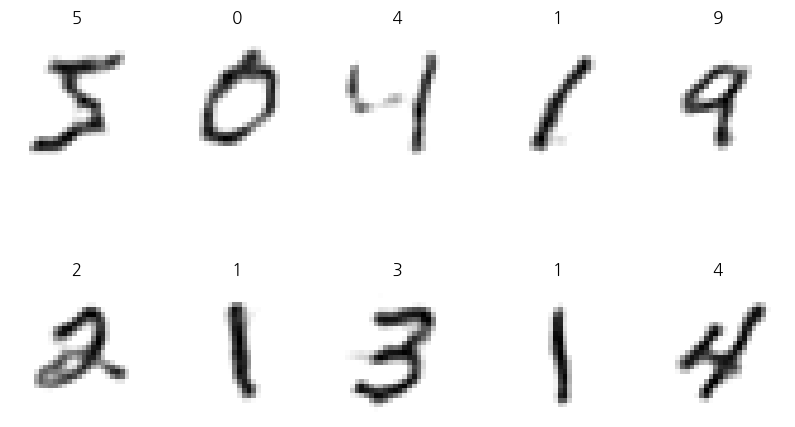

In [17]:
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(predict[i], cmap='Grays')
    plt.axis('off')
    plt.title(y_train[i])
plt.show()